# 36개월 전체 관측 법인 특성 EDA

36개월(2023.01~2025.12)을 모두 관측한 법인만을 안정 코호트로 정의해 업종·지역 구성, 금융 금액 추이, 고객별 변화와 변동성을 탐색합니다.

> 해석 주의: 이 노트북은 금융활동 특성을 설명하기 위한 EDA입니다. 활동 감소가 곧 확정 이탈이나 실제 손실을 뜻하지는 않습니다.

## tl;dr

이 노트북은 36개월이 모두 관측된 법인의 업종·지역과 다축 금융관계 추세를 점검합니다. 초기 6개월 평균 대비 지수는 축별 EDA 지표이며 종합점수가 아닙니다. 전체 합계·고객별 중앙값·상위 1% 영향 완화 결과와 rolling 다축 약화 민감도를 함께 보되, 여기서 y를 확정하지 않습니다.

## Context & Methods

### 분석 범위

- 기간: 2023.01~2025.12, 36개월
- 대상: 36개 달이 모두 관측된 법인
- 금융관계 축: 수신, 여신, 입출금, 외환, 카드, 채널, 자동이체, 상품관계폭
- 비교: 전체 코호트, 상위 업종·지역, 고객별 변화와 이상치 민감도

### Key Assumptions

- 관측행이 있는 월만 코호트 판단에 사용하며, 결측 고객-월을 0 활동으로 대체하지 않습니다.
- 업종·지역·등급·전담여부는 최근 관측월 기준 프로필을 사용하고 기간 중 변경 수를 별도로 확인합니다.
- 초기 6개월 평균 대비 지수는 각 축의 상대 추세 비교용이며 서로 다른 축을 합친 점수가 아닙니다.
- 금액은 명목금액이며 외부 경기·물가·제도 요인을 보정하지 않습니다.
- rolling 다축 약화 표의 임계값은 민감도 후보일 뿐 금융관계 휴면화 y가 아닙니다.

In [1]:
from pathlib import Path
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'src').exists():
    PROJECT_ROOT = Path('/Users/gggyyu/Final_project')
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.preprocessing.financial_dormancy_cohort import (
    build_financial_relationship_axes,
    select_complete_36m_cohort,
)
from src.preprocessing.financial_dormancy_candidates import (
    DormancyCandidateConfig,
    build_simple_dormancy_candidates,
)

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')
sns.set_theme(style='whitegrid', font_scale=0.95)
plt.rcParams['font.family'] = ['AppleGothic']
plt.rcParams['axes.unicode_minus'] = False

DATA_CANDIDATES = [
    Path('/Users/gggyyu/Desktop/(아이엠뱅크) 2026 교육용 데이터/(iM뱅크) 2026 교육용 법인 익명데이터.csv'),
    PROJECT_ROOT / 'data' / '법인 익명데이터.csv',
]
DATA_PATH = next((p for p in DATA_CANDIDATES if p.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError('원천 CSV를 찾지 못했습니다. DATA_CANDIDATES에 데이터 경로를 추가하세요.')

ID_COL, MONTH_COL = '법인ID', '기준년월'
PROFILE_COLS = ['업종_대분류', '업종_중분류', '사업장_시도', '사업장_시군구', '법인_고객등급', '전담고객여부']
DEPOSIT_COLS = ['요구불예금잔액', '거치식예금잔액', '적립식예금잔액', '수익증권잔액', '신탁잔액', '퇴직연금잔액']
LOAN_COLS = ['여신_운전자금대출잔액', '운전_할인어음잔액', '운전_당좌대출잔액', '운전_일반자금대출잔액', '운전_무역금융잔액', '운전_주택자금대출잔액', '운전_기업구매자금대출잔액', '운전_외상매출채권담보대출잔액', '운전_기타운전자금대출잔액', '여신_시설자금대출잔액', '시설_일반자금대출잔액', '시설_에너지절약시설대출잔액', '시설_주택자금대출잔액', '시설_기타시설자금대출잔액']
FLOW_COLS = ['요구불입금금액', '요구불출금금액']
FX_COLS = ['외환_수출실적금액', '외환_수입실적금액']
CARD_COLS = ['신용카드사용금액', '체크카드사용금액']
CHANNEL_COLS = ['창구거래금액', '인터넷뱅킹거래금액', '스마트뱅킹거래금액', '폰뱅킹거래금액', 'ATM거래금액']
AUTO_COLS = ['자동이체금액']
RAW_AMOUNT_COLS = DEPOSIT_COLS + LOAN_COLS + FLOW_COLS + FX_COLS + CARD_COLS + CHANNEL_COLS + AUTO_COLS
print(f'프로젝트 경로: {PROJECT_ROOT}')
print(f'원천 데이터: {DATA_PATH}')

프로젝트 경로: /Users/gggyyu/Final_project
원천 데이터: /Users/gggyyu/Desktop/(아이엠뱅크) 2026 교육용 데이터/(iM뱅크) 2026 교육용 법인 익명데이터.csv


## Data

### 1. Load and validate inputs

필요한 프로필·금액 컬럼만 읽고, 월/법인 키의 중복과 핵심 컬럼 결측을 점검합니다.

In [2]:
usecols = [ID_COL, MONTH_COL] + PROFILE_COLS + RAW_AMOUNT_COLS
df = pd.read_csv(DATA_PATH, usecols=usecols, encoding='utf-8-sig')
df[MONTH_COL] = pd.to_numeric(df[MONTH_COL], errors='raise').astype(int)
for col in RAW_AMOUNT_COLS:
    df[col] = pd.to_numeric(df[col], errors='coerce')

expected_months = pd.period_range(
    pd.to_datetime(str(df[MONTH_COL].min()), format='%Y%m'),
    pd.to_datetime(str(df[MONTH_COL].max()), format='%Y%m'), freq='M'
).strftime('%Y%m').astype(int).tolist()
key_duplicate_count = df.duplicated([ID_COL, MONTH_COL]).sum()

input_check = pd.DataFrame({
    '항목': ['행 수', '법인 수', '월 수', '월 범위', '법인-월 중복 행', '금액 컬럼 최대 결측률'],
    '값': [len(df), df[ID_COL].nunique(), df[MONTH_COL].nunique(), f'{df[MONTH_COL].min()} ~ {df[MONTH_COL].max()}', key_duplicate_count, df[RAW_AMOUNT_COLS].isna().mean().max()]
})
display(input_check)
assert key_duplicate_count == 0, '법인ID-기준년월 중복이 있어 코호트 정의 전에 정리가 필요합니다.'
assert sorted(df[MONTH_COL].unique()) == expected_months, '원천 전체 월이 연속적이지 않습니다. 기간 정의를 다시 확인하세요.'

,항목,값
0,행 수,365988
1,법인 수,15473
2,월 수,36
3,월 범위,202301 ~ 202512
4,법인-월 중복 행,0
5,금액 컬럼 최대 결측률,0.00


### 2. Define the 36-month stable cohort

36개월 각각이 관측된 법인만 포함합니다. 단순히 행 수가 36인 경우가 아니라, 기대한 모든 기준년월을 갖는지 확인합니다.

In [3]:
stable = select_complete_36m_cohort(
    df,
    customer_id_col=ID_COL,
    month_col=MONTH_COL,
    expected_start='2023-01',
    expected_end='2025-12',
)
stable_ids = pd.Index(stable[ID_COL].drop_duplicates())

cohort_summary = pd.DataFrame({
    '구분': ['전체 법인', '36개월 전체 관측 법인', '완전관측 코호트 비중', '완전관측 코호트 법인-월'],
    '값': [df[ID_COL].nunique(), len(stable_ids), len(stable_ids) / df[ID_COL].nunique(), len(stable)]
})
display(cohort_summary)
assert stable.groupby(ID_COL)[MONTH_COL].nunique().eq(36).all()
assert len(stable) == len(stable_ids) * 36

profile_change = stable.groupby(ID_COL)[PROFILE_COLS].nunique(dropna=False).gt(1).sum().sort_values(ascending=False).rename('프로필이 변한 법인 수').reset_index()
profile_change.columns = ['프로필 컬럼', '프로필이 변한 법인 수']
display(profile_change)

,구분,값
0,전체 법인,"15,473.00"
1,36개월 전체 관측 법인,"3,372.00"
2,완전관측 코호트 비중,0.22
3,완전관측 코호트 법인-월,"121,392.00"


,프로필 컬럼,프로필이 변한 법인 수
0,법인_고객등급,1976
1,전담고객여부,935
2,업종_대분류,0
3,업종_중분류,0
4,사업장_시도,0
5,사업장_시군구,0


## Results

### 3. Build RM-relevant financial activity measures

잔액·거래금액을 해석 가능한 여섯 묶음으로 만들고, 업종/지역은 최신월 프로필로 결합합니다.

In [4]:
stable = build_financial_relationship_axes(stable)
AMOUNT_METRIC_COLS = [
    '수신잔액합계', '여신잔액합계', '입출금금액', '외환거래금액',
    '카드사용금액', '채널거래금액', '자동이체금액'
]
LABEL_AMOUNT_METRIC_COLS = [
    '수신잔액합계', '여신잔액합계', '입출금금액',
    '외환거래금액', '카드사용금액', '자동이체금액'
]
METRIC_COLS = AMOUNT_METRIC_COLS + ['상품관계폭']

latest_profile = (stable.sort_values([ID_COL, MONTH_COL]).groupby(ID_COL).tail(1)[[ID_COL] + PROFILE_COLS].set_index(ID_COL))
activity_rate = stable.groupby(ID_COL)[METRIC_COLS].apply(lambda x: x.gt(0).mean()).add_suffix('_활성월비율')
customer_mean = stable.groupby(ID_COL)[METRIC_COLS].mean().add_suffix('_월평균')
customer_features = latest_profile.join(customer_mean).join(activity_rate).reset_index()
display(customer_features.head())

,법인ID,업종_대분류,업종_중분류,사업장_시도,사업장_시군구,법인_고객등급,전담고객여부,수신잔액합계_월평균,여신잔액합계_월평균,입출금금액_월평균,외환거래금액_월평균,카드사용금액_월평균,채널거래금액_월평균,자동이체금액_월평균,상품관계폭_월평균,수신잔액합계_활성월비율,여신잔액합계_활성월비율,입출금금액_활성월비율,외환거래금액_활성월비율,카드사용금액_활성월비율,채널거래금액_활성월비율,자동이체금액_활성월비율,상품관계폭_활성월비율
0,000fd5948a0ec34ce399733e5f9ce20477d0037286c99f...,숙박 및 음식점업,숙박업,경북,경상북도,우수,Y,18.49,"4,900.00",21.21,0.00,0.05,0.89,10.27,4.25,1.00,1.00,1.00,0.00,0.17,0.08,1.00,1.00
1,003c33dcf7856f7037b627ba17c959cbd74e07d1255d12...,도매 및 소매업,도매 및 상품 중개업,경북,경상북도,우수,N,0.41,652.78,10.18,0.00,0.82,3.50,3.15,5.47,0.78,1.00,1.00,0.00,0.97,0.72,1.00,1.00
2,0049899d0fdac0ff0724b8b9e1a38dd4296834622a356d...,제조업,고무 및 플라스틱제품 제조업,경북,경상북도,최우수,Y,363.50,269.42,"1,004.72",0.01,16.00,520.56,65.61,5.86,1.00,0.58,1.00,0.31,0.97,1.00,1.00,1.00
3,0079ed99f4faeeaa24e008b980d40794497fa29fbb6e5e...,제조업,1차 금속 제조업,대구,대구광역시,일반,N,0.98,91.61,8.08,0.00,0.00,4.29,0.85,5.00,1.00,1.00,1.00,0.00,0.00,1.00,1.00,1.00
4,007ce9339068d3e143f95000da5bcd649a64e50e04358b...,제조업,식료품 제조업,경북,경상북도,우수,Y,80.61,"2,139.00",274.61,0.00,1.23,120.09,21.79,5.97,1.00,1.00,1.00,0.00,0.97,1.00,1.00,1.00


### 4. Cohort composition: industry and region

고객 수와 월평균 금액을 함께 봅니다. 고객 수가 적은 범주는 평균이 불안정할 수 있어 상위 범주 중심으로 비교합니다.

,법인 수,월평균 6개 지표 합계,법인 비중
업종_대분류,,,
제조업,1093,"7,803.33",0.32
도매 및 소매업,706,"5,269.20",0.21
건설업,583,"3,606.78",0.17
부동산업,269,"7,146.30",0.08
운수 및 창고업,142,"2,640.29",0.04
"사업시설 관리, 사업 지원 및 임대 서비스업",107,"3,293.00",0.03
"전문, 과학 및 기술 서비스업",83,"2,591.32",0.02
"협회 및 단체, 수리 및 기타 개인 서비스업",82,"3,089.20",0.02
숙박 및 음식점업,60,"8,284.51",0.02


,법인 수,월평균 6개 지표 합계,법인 비중
사업장_시도,,,
대구,1498,"5,808.44",0.46
경북,1198,"5,410.34",0.37
수도권,248,"34,474.01",0.08
부울경,237,"5,672.50",0.07
기타,42,"4,695.40",0.01


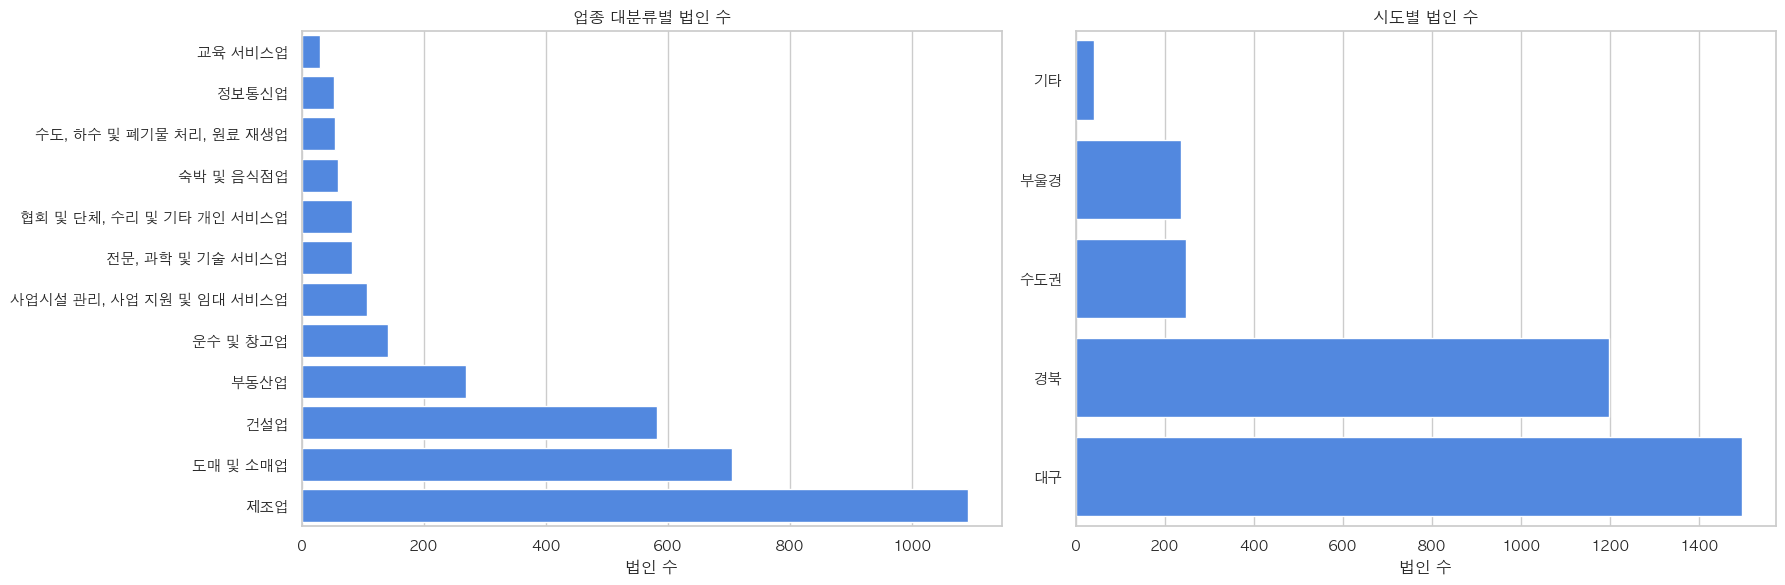

In [5]:
def composition_table(data, group_col):
    customer_base = data.sort_values(MONTH_COL).groupby(ID_COL).tail(1)
    counts = customer_base.groupby(group_col)[ID_COL].nunique().rename('법인 수')
    values = data.groupby(group_col)[METRIC_COLS].mean().sum(axis=1).rename('월평균 6개 지표 합계')
    out = pd.concat([counts, values], axis=1).sort_values('법인 수', ascending=False)
    out['법인 비중'] = out['법인 수'] / out['법인 수'].sum()
    return out

industry_composition = composition_table(stable, '업종_대분류')
region_composition = composition_table(stable, '사업장_시도')
display(industry_composition)
display(region_composition)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
for ax, table, title in zip(axes, [industry_composition, region_composition], ['업종 대분류별 법인 수', '시도별 법인 수']):
    plot_data = table.head(12).sort_values('법인 수')
    sns.barplot(data=plot_data, x='법인 수', y=plot_data.index, ax=ax, color='#3B82F6')
    ax.set_title(title)
    ax.set_xlabel('법인 수')
    ax.set_ylabel('')
plt.tight_layout()
plt.show()

### 5. Monthly financial trends

전체 코호트의 월별 합계와 고객당 평균을 확인합니다. 지표 단위가 크게 다르므로, 첫 달을 100으로 둔 지수도 함께 표시합니다.

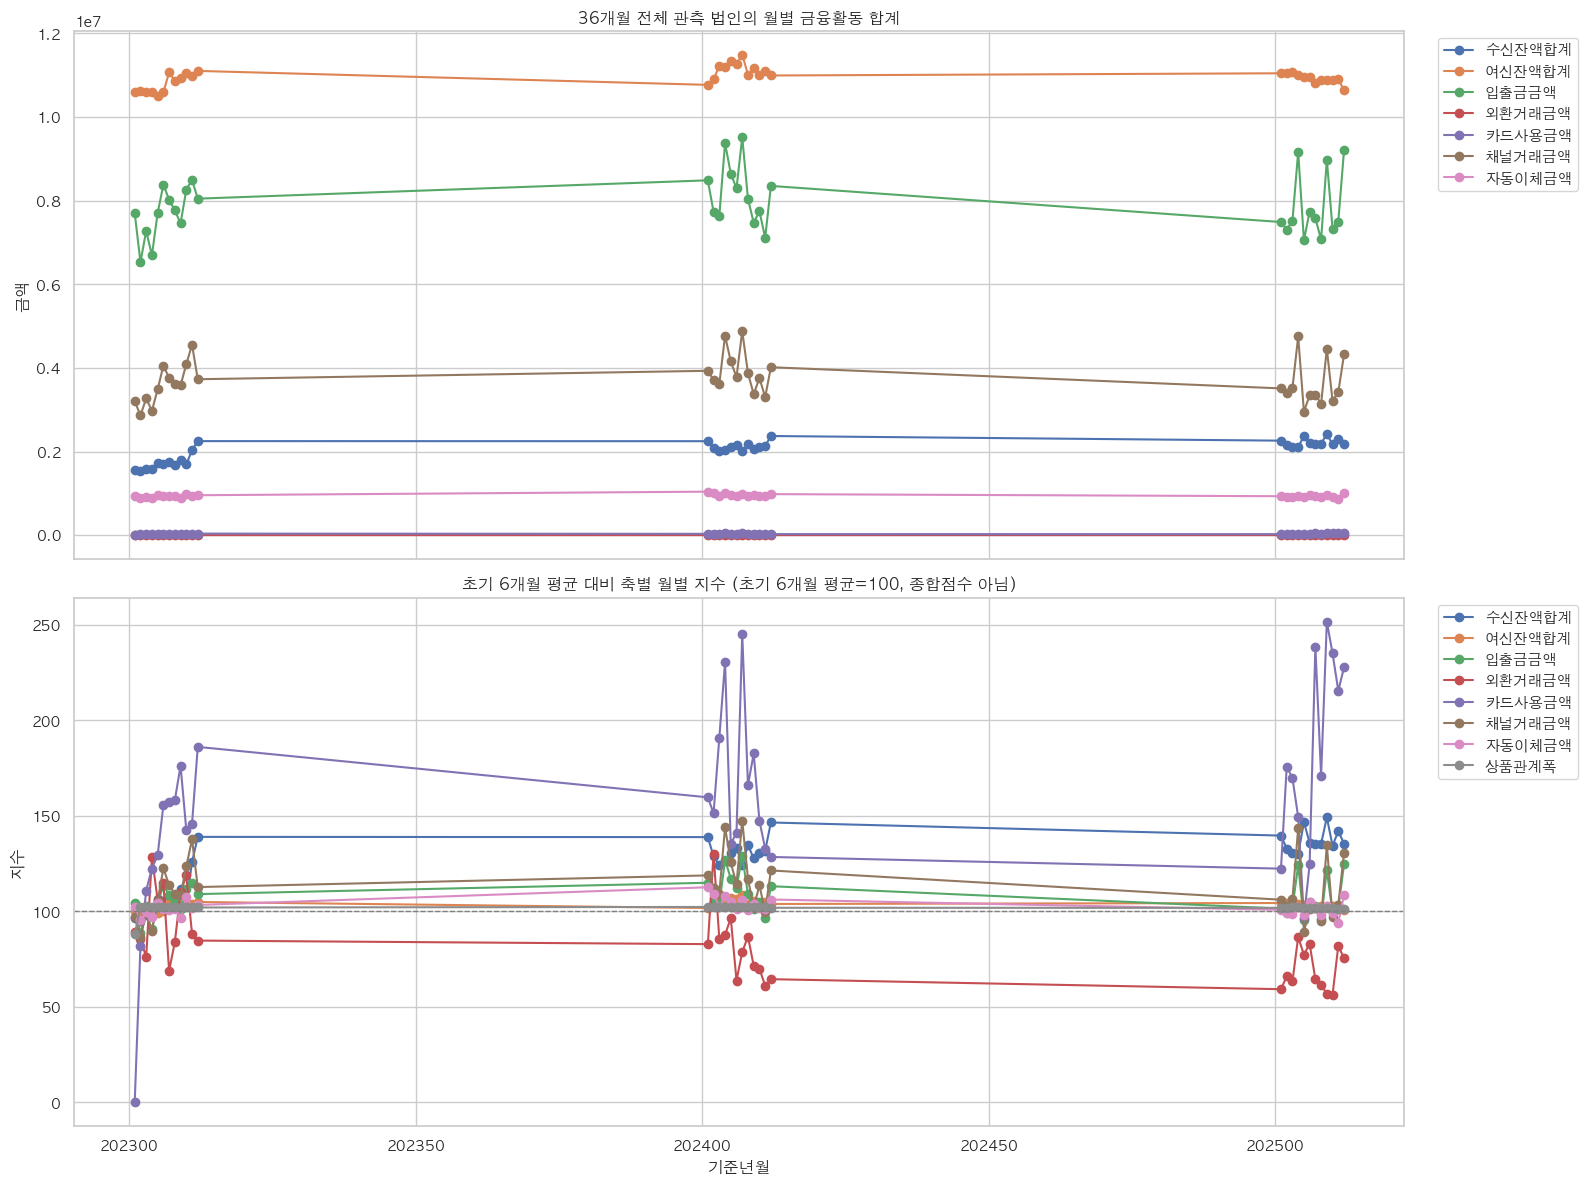

,지표,초기 6개월 평균 합계,마지막 달 합계,합계 변화율,초기 6개월 고객당 평균,마지막 달 고객당 평균
0,수신잔액합계,"1,617,893.38","2,190,792.73",0.35,479.80,649.70
1,여신잔액합계,"10,585,719.62","10,635,887.93",0.00,"3,139.30","3,154.18"
2,입출금금액,"7,381,647.91","9,203,846.52",0.25,"2,189.10","2,729.49"
3,외환거래금액,58.66,44.22,-0.25,0.02,0.01
4,카드사용금액,"19,626.54","44,707.81",1.28,5.82,13.26
5,채널거래금액,"3,308,316.90","4,321,539.04",0.31,981.11,"1,281.60"
6,자동이체금액,"923,830.56","1,002,851.20",0.09,273.97,297.41
7,상품관계폭,"18,175.00","18,401.00",0.01,5.39,5.46


In [6]:
monthly_total = stable.groupby(MONTH_COL)[METRIC_COLS].sum()
monthly_per_customer = stable.groupby(MONTH_COL)[METRIC_COLS].mean()
initial_6m_total = monthly_total.head(6).mean().replace(0, np.nan)
initial_6m_per_customer = monthly_per_customer.head(6).mean().replace(0, np.nan)
monthly_index = monthly_total.div(initial_6m_total).mul(100)

fig, axes = plt.subplots(2, 1, figsize=(16, 12), sharex=True)
monthly_total[AMOUNT_METRIC_COLS].plot(ax=axes[0], marker='o')
axes[0].set_title('36개월 전체 관측 법인의 월별 금융활동 합계')
axes[0].set_ylabel('금액')
axes[0].legend(bbox_to_anchor=(1.02, 1), loc='upper left')

monthly_index.plot(ax=axes[1], marker='o')
axes[1].axhline(100, color='gray', linestyle='--', linewidth=1)
axes[1].set_title('초기 6개월 평균 대비 축별 월별 지수 (초기 6개월 평균=100, 종합점수 아님)')
axes[1].set_ylabel('지수')
axes[1].set_xlabel('기준년월')
axes[1].legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

trend_summary = pd.DataFrame({
    '지표': METRIC_COLS,
    '초기 6개월 평균 합계': initial_6m_total.values,
    '마지막 달 합계': monthly_total.iloc[-1].values,
    '합계 변화율': (monthly_total.iloc[-1].values / initial_6m_total.values - 1),
    '초기 6개월 고객당 평균': initial_6m_per_customer.values,
    '마지막 달 고객당 평균': monthly_per_customer.iloc[-1].values,
})
display(trend_summary)

### 5-1. 지수 추이의 강건성 점검

초기 6개월 평균 대비 지수는 축별 상대 추세를 비교하는 EDA 지표입니다. 첫 달 값이 0인 축과 단월 특이값을 피하면서 다음 세 관점을 함께 비교합니다.

1. 전체 법인 합계의 초기 6개월 평균 대비 지수
2. 법인별 초기 6개월 평균 대비 지수를 만든 뒤 월별 중앙값
3. 고객-월 금액의 상위 1%를 완화한 합계 지수

초기 6개월 평균이 0인 법인은 고객별 지수 중앙값에서 제외하고 그 수를 별도로 공개합니다.

,지표,초기 6개월 평균 합계,고객별 초기 6개월 평균 0 법인 수,상위 1% cap
0,수신잔액합계,"1,617,893.38",114,"7,580.00"
1,여신잔액합계,"10,585,719.62",198,"41,609.00"
2,입출금금액,"7,381,647.91",17,"26,400.00"
3,외환거래금액,58.66,3196,0.20
4,카드사용금액,"19,626.54",664,50.00
5,채널거래금액,"3,308,316.90",172,"12,903.53"
6,자동이체금액,"923,830.56",19,"2,000.00"
7,상품관계폭,"18,175.00",2,NaN


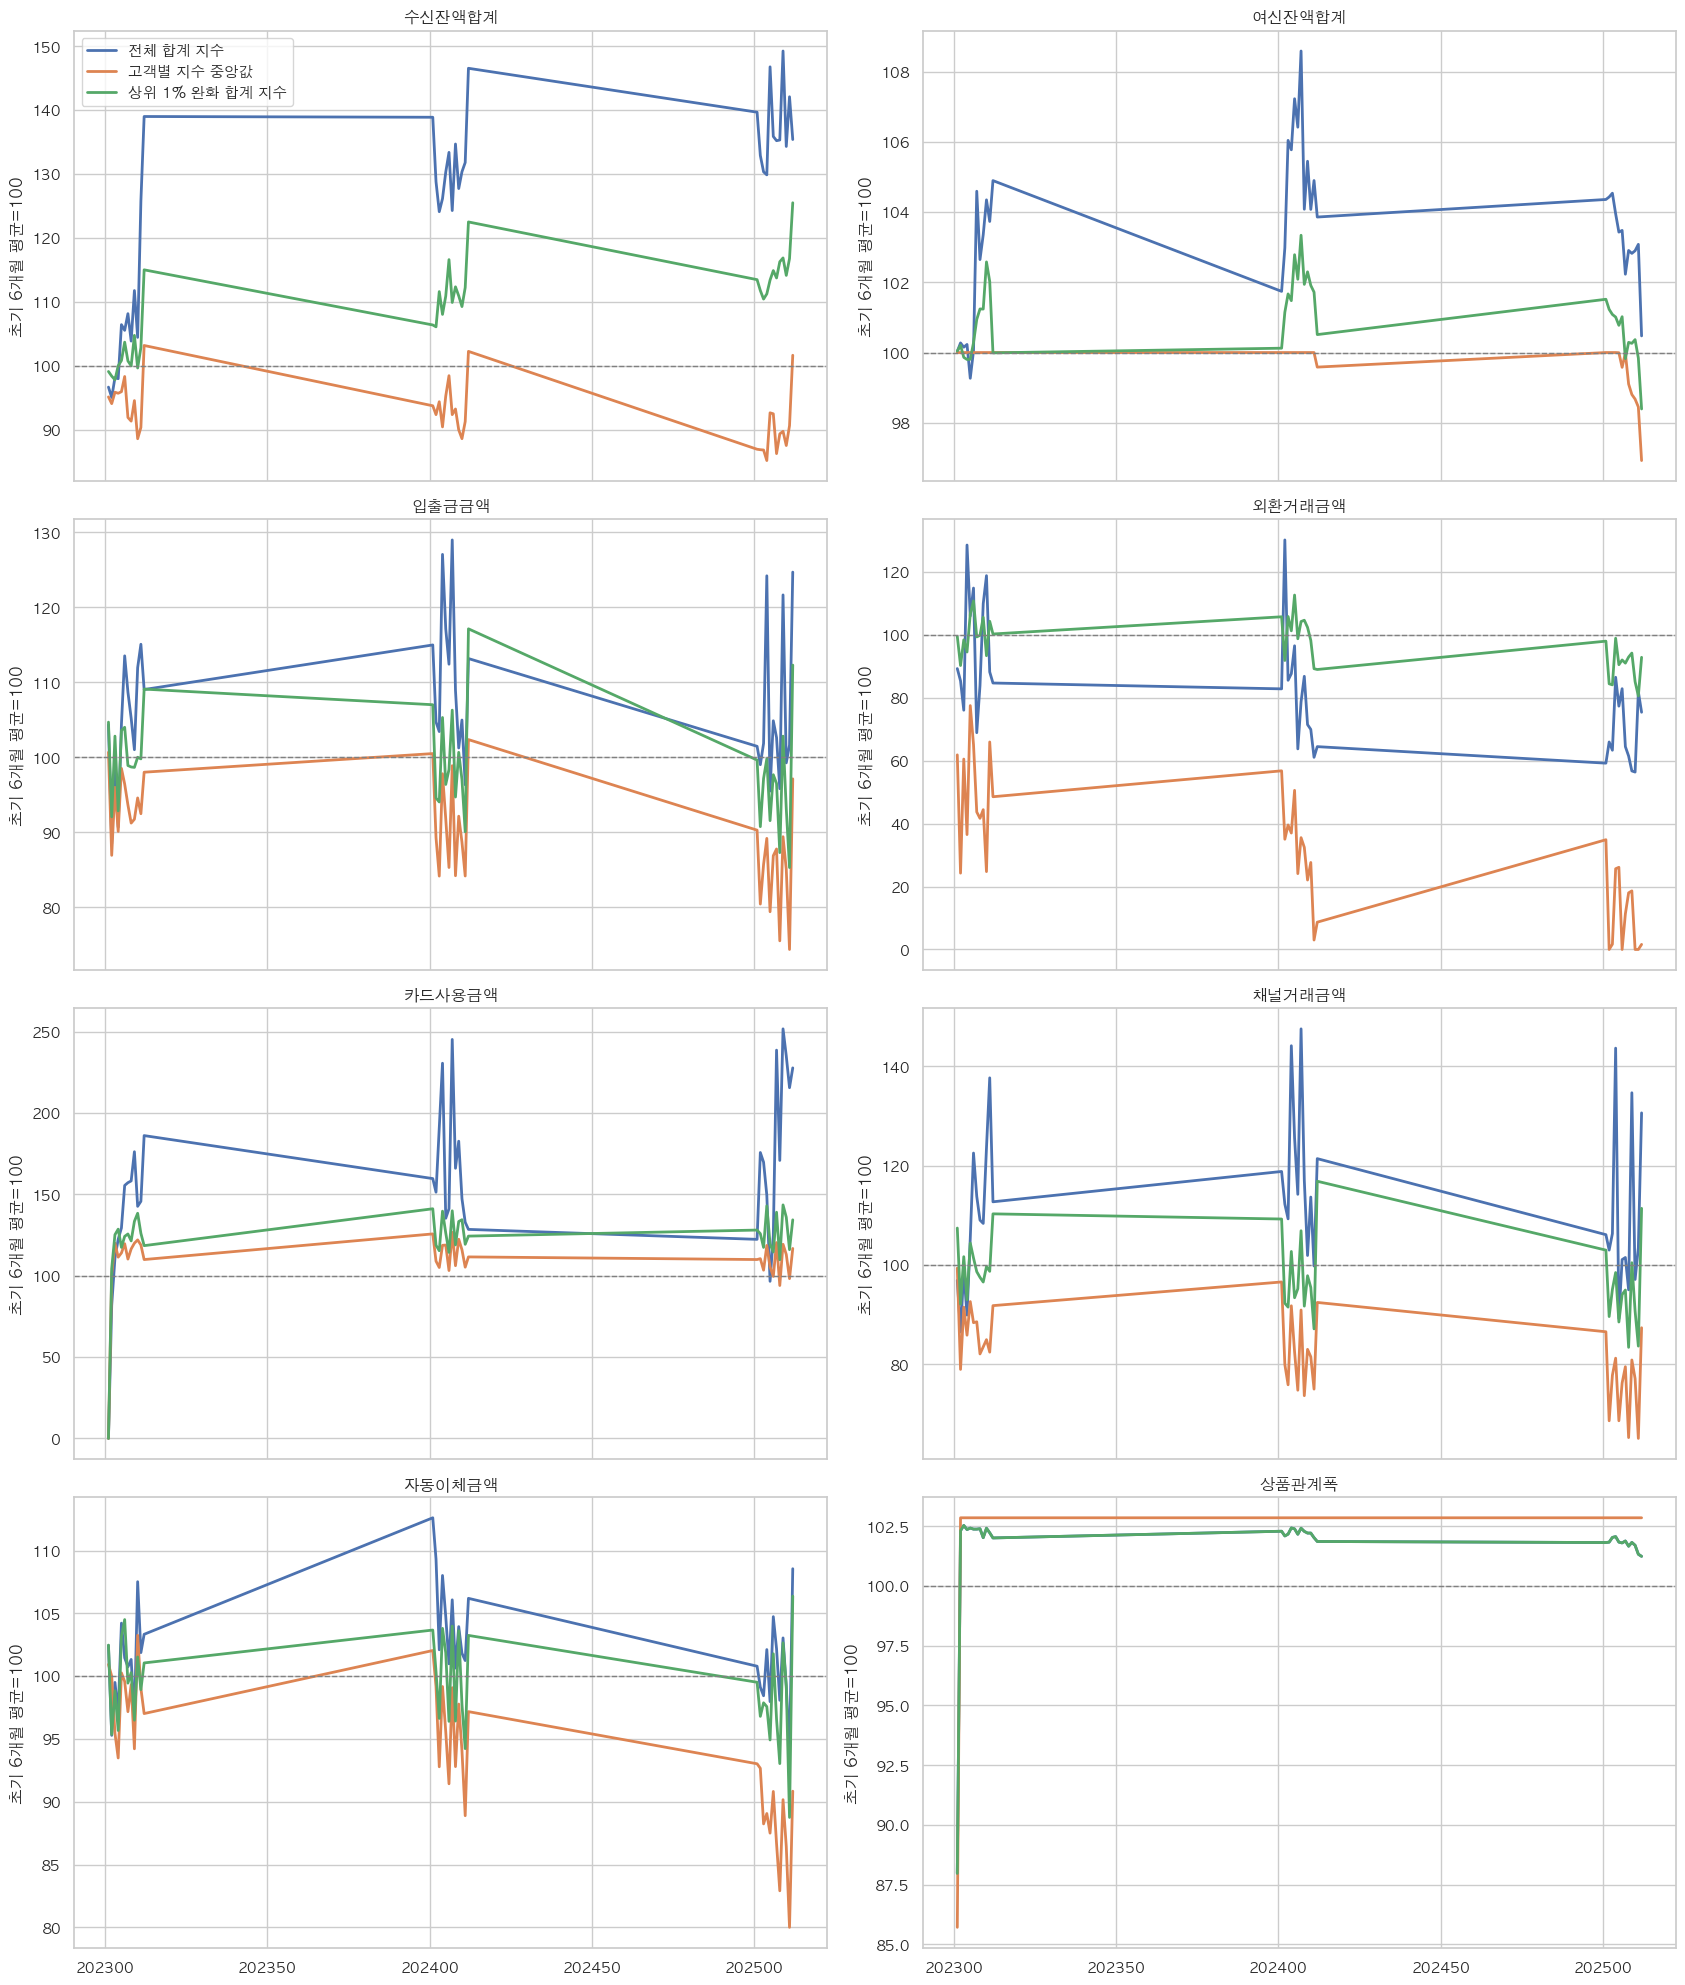

,지표,전체 합계 지수,고객별 지수 중앙값,상위 1% 완화 합계 지수
0,수신잔액합계,135.41,101.68,125.52
1,여신잔액합계,100.47,96.92,98.39
2,입출금금액,124.69,97.13,112.29
3,외환거래금액,75.39,1.62,92.85
4,카드사용금액,227.79,116.77,134.37
5,채널거래금액,130.63,87.36,111.40
6,자동이체금액,108.55,90.84,106.37
7,상품관계폭,101.24,102.86,101.24


In [7]:
# ROBUST_INDEX_CHECK_V1
ordered = stable.sort_values([ID_COL, MONTH_COL]).copy()
customer_baseline = (
    ordered.groupby(ID_COL, sort=False).head(6)
    .groupby(ID_COL)[METRIC_COLS].mean()
    .replace(0, np.nan)
)
customer_index_rows = (
    ordered.set_index(ID_COL)[METRIC_COLS]
    .div(customer_baseline)
    .mul(100)
)
customer_index_rows[MONTH_COL] = ordered.set_index(ID_COL)[MONTH_COL]
customer_median_index = customer_index_rows.groupby(MONTH_COL)[METRIC_COLS].median()

winsor_caps = ordered[AMOUNT_METRIC_COLS].quantile(0.99)
winsorized = ordered.copy()
winsorized[AMOUNT_METRIC_COLS] = winsorized[AMOUNT_METRIC_COLS].clip(upper=winsor_caps, axis=1)
winsor_monthly_total = winsorized.groupby(MONTH_COL)[METRIC_COLS].sum()
winsor_initial_6m_total = winsor_monthly_total.head(6).mean().replace(0, np.nan)
winsor_monthly_index = winsor_monthly_total.div(winsor_initial_6m_total).mul(100)

baseline_check = pd.DataFrame({
    '지표': METRIC_COLS,
    '초기 6개월 평균 합계': initial_6m_total.values,
    '고객별 초기 6개월 평균 0 법인 수': customer_baseline.isna().sum().values,
    '상위 1% cap': [winsor_caps.get(metric, np.nan) for metric in METRIC_COLS],
})
display(baseline_check)

fig, axes = plt.subplots(4, 2, figsize=(17, 20), sharex=True)
for metric, ax in zip(METRIC_COLS, axes.ravel()):
    ax.plot(monthly_index.index, monthly_index[metric], label='전체 합계 지수', linewidth=2)
    ax.plot(customer_median_index.index, customer_median_index[metric], label='고객별 지수 중앙값', linewidth=2)
    ax.plot(winsor_monthly_index.index, winsor_monthly_index[metric], label='상위 1% 완화 합계 지수', linewidth=2)
    ax.axhline(100, color='gray', linestyle='--', linewidth=1)
    ax.set_title(metric)
    ax.set_ylabel('초기 6개월 평균=100')
axes[0, 0].legend(loc='best')
plt.tight_layout()
plt.show()

robust_last_month = pd.DataFrame({
    '지표': METRIC_COLS,
    '전체 합계 지수': monthly_index.iloc[-1].values,
    '고객별 지수 중앙값': customer_median_index.iloc[-1].values,
    '상위 1% 완화 합계 지수': winsor_monthly_index.iloc[-1].values,
})
display(robust_last_month)

### 6. Industry and region trend comparison

고객 수 상위 업종·지역만 표시하고, 각 집단의 첫 달을 100으로 표준화합니다. 따라서 그래프는 절대 규모가 아니라 상대 변화 방향을 보여줍니다.

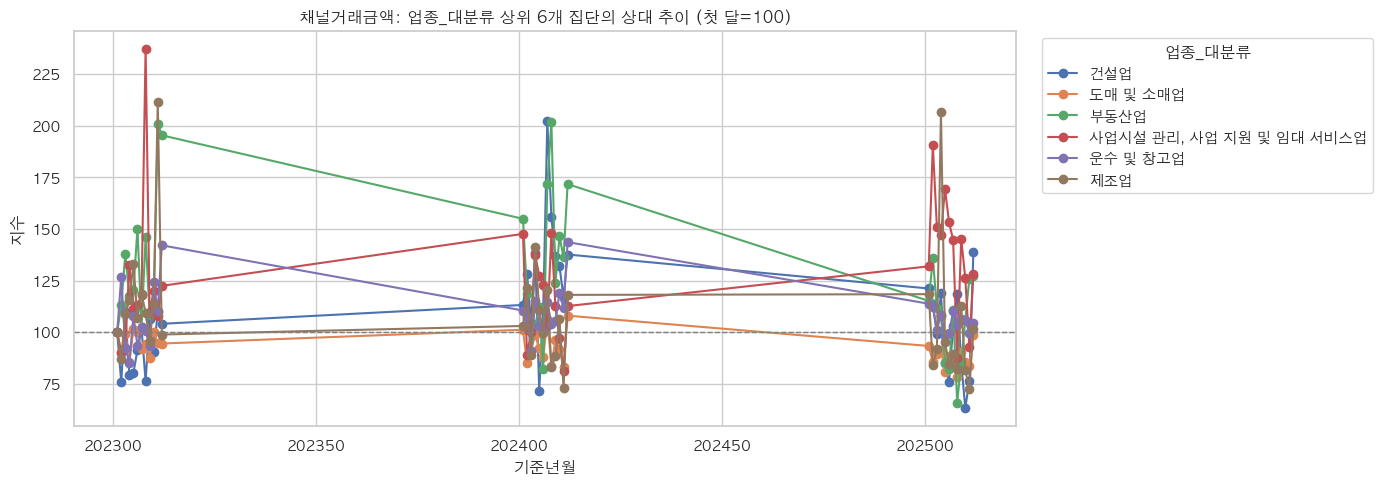

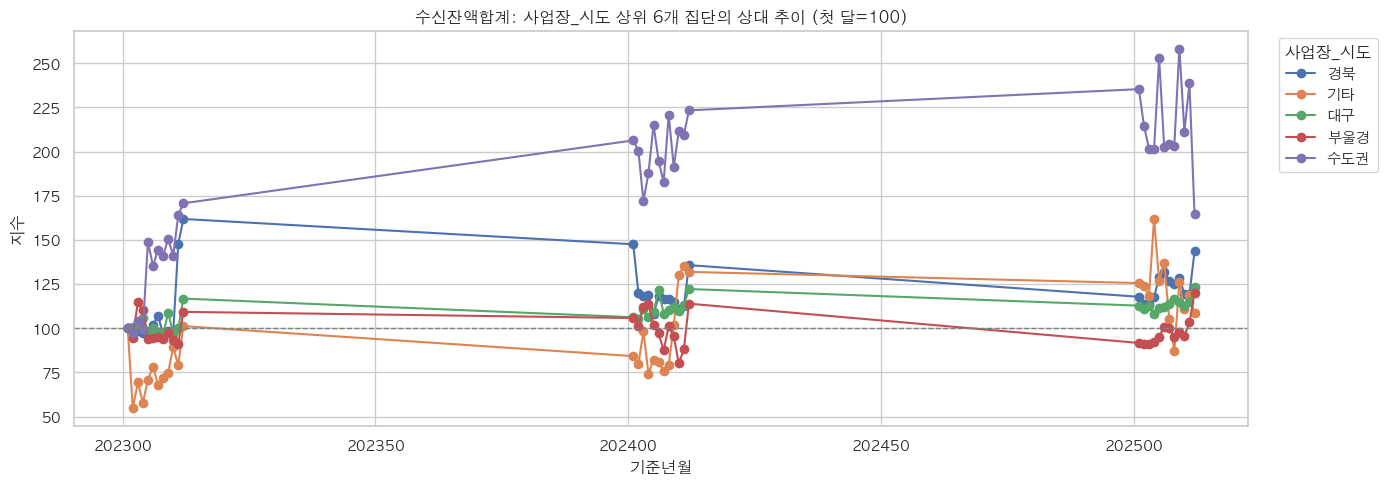

In [8]:
def plot_group_index(data, group_col, metric, top_n=6):
    top_groups = data.groupby(group_col)[ID_COL].nunique().nlargest(top_n).index
    grouped = data[data[group_col].isin(top_groups)].groupby([MONTH_COL, group_col])[metric].sum().unstack(group_col)
    indexed = grouped.div(grouped.iloc[0]).mul(100)
    ax = indexed.plot(figsize=(14, 5), marker='o')
    ax.axhline(100, color='gray', linestyle='--', linewidth=1)
    ax.set_title(f'{metric}: {group_col} 상위 {top_n}개 집단의 상대 추이 (첫 달=100)')
    ax.set_ylabel('지수')
    ax.set_xlabel('기준년월')
    ax.legend(title=group_col, bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

plot_group_index(stable, '업종_대분류', '채널거래금액')
plot_group_index(stable, '사업장_시도', '수신잔액합계')

### 7. Customer-level change and volatility

각 법인의 처음 6개월 평균과 최근 6개월 평균을 비교합니다. 분모가 0인 고객은 변화율 대신 별도 상태로 분류해, 0에서 발생한 활동을 과도한 증가율로 해석하지 않습니다.

,지표,기준>0 법인 수,중앙 변화율,감소 법인 비중,50% 이상 감소 비중,중앙 변동계수
0,수신잔액합계,3258,0.06,0.45,0.24,0.81
1,여신잔액합계,3174,-0.02,0.49,0.14,0.11
2,입출금금액,3355,-0.07,0.56,0.17,0.54
3,외환거래금액,176,-0.46,0.04,0.02,2.23
4,카드사용금액,2708,0.22,0.29,0.12,0.59
5,채널거래금액,3200,-0.10,0.54,0.22,0.72
6,자동이체금액,3353,-0.11,0.61,0.15,0.32
7,상품관계폭,3370,0.03,0.19,0.00,0.04


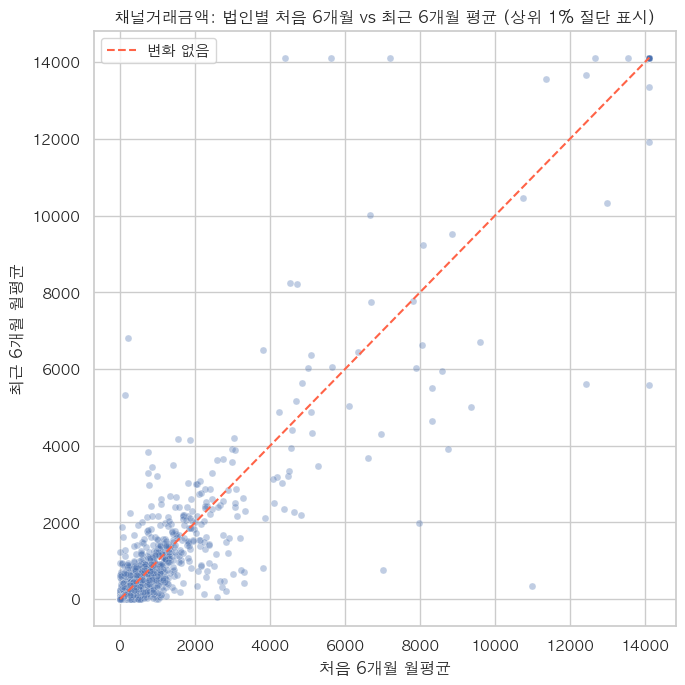

In [9]:
first6 = stable.sort_values([ID_COL, MONTH_COL]).groupby(ID_COL).head(6).groupby(ID_COL)[METRIC_COLS].mean()
last6 = stable.sort_values([ID_COL, MONTH_COL]).groupby(ID_COL).tail(6).groupby(ID_COL)[METRIC_COLS].mean()
change_ratio = last6.divide(first6.replace(0, np.nan)).sub(1)
volatility = stable.groupby(ID_COL)[METRIC_COLS].std().divide(stable.groupby(ID_COL)[METRIC_COLS].mean().replace(0, np.nan)).replace([np.inf, -np.inf], np.nan)

change_summary = pd.DataFrame({
    '지표': METRIC_COLS,
    '기준>0 법인 수': change_ratio.notna().sum().values,
    '중앙 변화율': change_ratio.median().values,
    '감소 법인 비중': change_ratio.lt(0).mean().values,
    '50% 이상 감소 비중': change_ratio.lt(-0.5).mean().values,
    '중앙 변동계수': volatility.median().values,
})
display(change_summary)

plot_metric = '채널거래금액'
plot_df = pd.DataFrame({'처음 6개월 월평균': first6[plot_metric], '최근 6개월 월평균': last6[plot_metric]}).replace(0, np.nan).dropna()
limit = plot_df.quantile(0.99).max()
plt.figure(figsize=(7, 7))
sns.scatterplot(data=plot_df.clip(upper=limit), x='처음 6개월 월평균', y='최근 6개월 월평균', alpha=0.35, s=25)
plt.plot([0, limit], [0, limit], '--', color='tomato', label='변화 없음')
plt.title(f'{plot_metric}: 법인별 처음 6개월 vs 최근 6개월 평균 (상위 1% 절단 표시)')
plt.legend()
plt.tight_layout()
plt.show()

### 7-1. 다축 약화상태 후보 탐색

여기서는 y를 확정하지 않습니다. rolling y의 미래 사건을 설계하기 전에, 기준월까지 관측 가능한 최근 3개월과 그 이전 6개월을 비교해 **동시에 약해진 축 수**가 데이터에서 어떻게 분포하는지 탐색합니다.

약화비율과 필요한 축 수를 여러 값으로 바꾸어 발생 규모가 지나치게 작거나 큰 조건을 걸러냅니다. 이 표는 후보 민감도이며 학습 정답이 아닙니다.

,축별 최근/이전 비율 기준,최소 동시 약화 축 수,판정가능 법인-월,약화상태 법인-월,약화상태 비율,해당 법인 수
0,0.30,2,94384,6758,0.07,1437
1,0.30,3,94091,2038,0.02,663
2,0.30,4,93976,396,0.00,181
3,0.50,2,94384,14431,0.15,2242
4,0.50,3,94091,5422,0.06,1354
5,0.50,4,93976,1378,0.01,544
6,0.70,2,94384,28605,0.30,3050
7,0.70,3,94091,13397,0.14,2391
8,0.70,4,93976,4442,0.05,1325


,법인-월 수,비율
동시 약화 축 수,,
0,55193,0.58
1,24760,0.26
2,9009,0.10
3,4044,0.04
4,1121,0.01
5,220,0.00
6,35,0.00
7,2,0.00


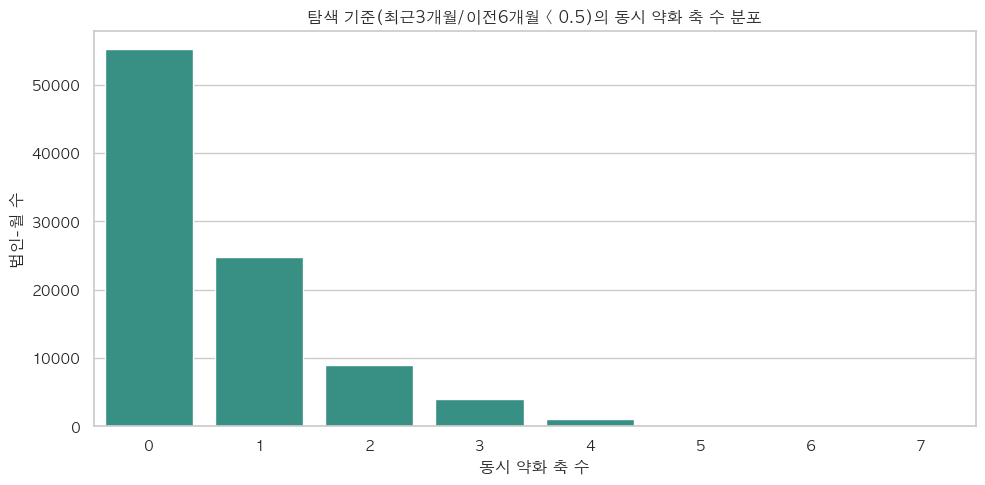

In [10]:
# MULTI_AXIS_WEAKENING_EXPLORATION_V1
rolling_source = stable.sort_values([ID_COL, MONTH_COL]).copy()
ratio_columns = []

for metric in METRIC_COLS:
    recent_3m = rolling_source.groupby(ID_COL, sort=False)[metric].transform(
        lambda values: values.rolling(3, min_periods=3).mean()
    )
    prior_6m = rolling_source.groupby(ID_COL, sort=False)[metric].transform(
        lambda values: values.shift(3).rolling(6, min_periods=6).mean()
    )
    ratio_col = f'{metric}_최근3개월_이전6개월비'
    rolling_source[ratio_col] = recent_3m.divide(prior_6m.replace(0, np.nan))
    ratio_columns.append(ratio_col)

sensitivity_rows = []
for ratio_threshold in [0.3, 0.5, 0.7]:
    weakened = rolling_source[ratio_columns].lt(ratio_threshold)
    for min_axes in [2, 3, 4]:
        candidate = weakened.sum(axis=1).ge(min_axes)
        eligible = rolling_source[ratio_columns].notna().sum(axis=1).ge(min_axes)
        candidate_eligible = candidate & eligible
        sensitivity_rows.append({
            '축별 최근/이전 비율 기준': ratio_threshold,
            '최소 동시 약화 축 수': min_axes,
            '판정가능 법인-월': int(eligible.sum()),
            '약화상태 법인-월': int(candidate_eligible.sum()),
            '약화상태 비율': candidate_eligible.sum() / eligible.sum() if eligible.sum() else np.nan,
            '해당 법인 수': rolling_source.loc[candidate_eligible, ID_COL].nunique(),
        })

weakening_sensitivity = pd.DataFrame(sensitivity_rows)
display(weakening_sensitivity)

reference_threshold = 0.5
rolling_source['동시약화축수_탐색용'] = rolling_source[ratio_columns].lt(reference_threshold).sum(axis=1)
axis_count_distribution = (
    rolling_source.loc[rolling_source[ratio_columns].notna().any(axis=1), '동시약화축수_탐색용']
    .value_counts()
    .sort_index()
    .rename_axis('동시 약화 축 수')
    .to_frame('법인-월 수')
)
axis_count_distribution['비율'] = axis_count_distribution['법인-월 수'] / axis_count_distribution['법인-월 수'].sum()
display(axis_count_distribution)

plt.figure(figsize=(10, 5))
sns.barplot(data=axis_count_distribution.reset_index(), x='동시 약화 축 수', y='법인-월 수', color='#2A9D8F')
plt.title('탐색 기준(최근3개월/이전6개월 < 0.5)의 동시 약화 축 수 분포')
plt.tight_layout()
plt.show()

### 7-2. 입출금·채널 중복성 점검

입출금금액은 요구불계좌의 입·출금 규모이고, 채널거래금액은 그 거래가 창구·인터넷·스마트·폰·ATM에서 처리된 규모입니다. 두 축은 의미가 완전히 같지는 않지만 동일 거래활동을 중복 집계할 수 있으므로 원값 상관과 50% 감소 플래그의 동시발생을 확인합니다.

채널거래금액은 y 판정축에서 제외하고, 이후 모델 feature와 약화 원인 설명에는 유지합니다.

In [11]:
# CHANNEL_FLOW_OVERLAP_V1
overlap_config = DormancyCandidateConfig(
    amount_axes=('입출금금액', '채널거래금액'),
    recent_months=3,
    reference_months=6,
    future_months=3,
    drop_threshold=0.5,
    min_axes_candidates=(2,),
)
overlap_panel = build_simple_dormancy_candidates(stable, overlap_config)
flow_decline = overlap_panel['50%이상감소_입출금금액'].astype(bool)
channel_decline = overlap_panel['50%이상감소_채널거래금액'].astype(bool)
overlap_valid = (
    overlap_panel['금액감소율_입출금금액'].notna()
    & overlap_panel['금액감소율_채널거래금액'].notna()
)
flow_decline_valid = flow_decline[overlap_valid]
channel_decline_valid = channel_decline[overlap_valid]
both_decline = flow_decline_valid & channel_decline_valid
either_decline = flow_decline_valid | channel_decline_valid

channel_flow_overlap = pd.DataFrame({
    '점검지표': [
        '원금액 Pearson 상관',
        '원금액 Spearman 상관',
        '채널금액≤입출금금액 비율',
        '입출금 50% 감소 비율',
        '채널 50% 감소 비율',
        '입출금 감소 중 채널도 감소 비율',
        '감소 플래그 Jaccard',
    ],
    '값': [
        stable['입출금금액'].corr(stable['채널거래금액'], method='pearson'),
        stable['입출금금액'].corr(stable['채널거래금액'], method='spearman'),
        stable['채널거래금액'].le(stable['입출금금액']).mean(),
        flow_decline_valid.mean(),
        channel_decline_valid.mean(),
        both_decline.sum() / flow_decline_valid.sum(),
        both_decline.sum() / either_decline.sum(),
    ],
})
display(channel_flow_overlap)

assert channel_flow_overlap.loc[channel_flow_overlap['점검지표'].eq('원금액 Spearman 상관'), '값'].notna().all()
assert overlap_valid.any()


,점검지표,값
0,원금액 Pearson 상관,0.84
1,원금액 Spearman 상관,0.95
2,채널금액≤입출금금액 비율,1.00
3,입출금 50% 감소 비율,0.11
4,채널 50% 감소 비율,0.18
5,입출금 감소 중 채널도 감소 비율,0.89
6,감소 플래그 Jaccard,0.49


### 7-3. 채널 제외 단순 금액감소 rolling y 후보

복잡한 점수나 가중합 없이 금액 감소만 사용합니다.

```text
축별 큰 감소 = 최근 3개월 평균이 바로 이전 6개월 평균의 50% 이하
y(t)=1 = 현재는 해당 상태가 아니지만, 향후 3개월 안에 큰 감소 축이 기준 개수 이상 발생
```

수신·여신·입출금·외환·카드·자동이체 6개 축을 각각 판정합니다. 채널거래금액은 입출금과의 중복을 피하기 위해 y에서 제외합니다. 이전 6개월 평균이 0인 축은 감소 판정에서 제외합니다.

- `Y_단순휴면_2축`: 넓은 후보
- `Y_단순휴면_3축`: 중간 후보
- `Y_단순휴면_4축`: 엄격한 후보

세 후보를 나란히 비교하며, 이 단계에서는 어느 하나를 최종 y로 확정하지 않습니다.

,y 후보,학습가능 법인-월,y=1 법인-월,y=1 비율,y=1 경험 법인 수
0,향후3개월_2축이상_50%감소,76278,7968,0.10,1702
1,향후3개월_3축이상_50%감소,82211,2193,0.03,608
2,향후3개월_4축이상_50%감소,81826,424,0.01,148


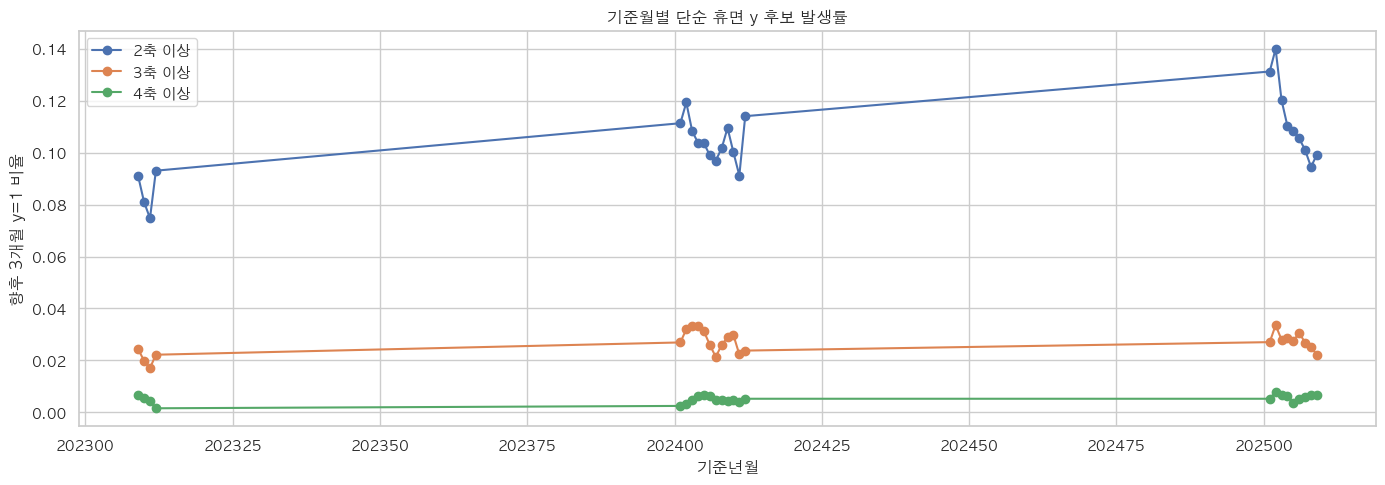

,금융축,y=1 중 미래3개월 감소 포함 비율
2,입출금금액,0.84
0,수신잔액합계,0.80
4,카드사용금액,0.65
5,자동이체금액,0.58
1,여신잔액합계,0.24
3,외환거래금액,0.11


,법인월수,y_1_법인월,y_1_비율,법인수,전체대비차이,후보,구분
업종_대분류,,,,,,,
건설업,12244,2351,0.19,582,0.09,2축 이상,업종_대분류
"농업, 임업 및 어업",110,21,0.19,5,0.09,2축 이상,업종_대분류
정보통신업,1212,142,0.12,53,0.01,2축 이상,업종_대분류
금융 및 보험업,495,52,0.11,22,0.00,2축 이상,업종_대분류
"전문, 과학 및 기술 서비스업",1868,192,0.10,82,-0.00,2축 이상,업종_대분류
부동산업,5943,605,0.10,266,-0.00,2축 이상,업종_대분류
"사업시설 관리, 사업 지원 및 임대 서비스업",2460,247,0.10,107,-0.00,2축 이상,업종_대분류
"전기, 가스, 증기 및 공기조절 공급업",579,57,0.10,25,-0.01,2축 이상,업종_대분류
제조업,24962,2385,0.10,1090,-0.01,2축 이상,업종_대분류


,법인월수,y_1_법인월,y_1_비율,법인수,전체대비차이,후보,구분
사업장_시도,,,,,,,
수도권,5304,679,0.13,242,0.02,2축 이상,사업장_시도
부울경,5233,626,0.12,237,0.02,2축 이상,사업장_시도
기타,925,99,0.11,41,0.00,2축 이상,사업장_시도
NaN,3357,348,0.10,148,-0.00,2축 이상,사업장_시도
대구,34070,3490,0.10,1497,-0.00,2축 이상,사업장_시도
경북,27389,2726,0.10,1197,-0.00,2축 이상,사업장_시도
기타,994,39,0.04,41,0.01,3축 이상,사업장_시도
수도권,5771,201,0.03,239,0.01,3축 이상,사업장_시도
부울경,5726,186,0.03,236,0.01,3축 이상,사업장_시도


,월평균 발생률,월최소 발생률,월최대 발생률,월표준편차,월변동계수,월최소 학습가능 법인월,월최대 학습가능 법인월
2축 이상,0.10,0.07,0.14,0.01,0.14,2999,3116
3축 이상,0.03,0.02,0.03,0.00,0.16,3275,3313
4축 이상,0.01,0.00,0.01,0.00,0.29,3264,3285


,,최소발생률,최대발생률,평균발생률,표준편차,세그먼트
후보,구분,,,,,
2축 이상,업종_대분류,0.03,0.19,0.09,0.04,업종
3축 이상,업종_대분류,0.00,0.06,0.02,0.01,업종
4축 이상,업종_대분류,0.00,0.01,0.00,0.00,업종
2축 이상,사업장_시도,0.10,0.13,0.11,0.01,지역
3축 이상,사업장_시도,0.02,0.04,0.03,0.01,지역
4축 이상,사업장_시도,0.00,0.01,0.01,0.00,지역


,학습가능_법인월,y_1_법인월,y_1_비율,법인수
판정가능축수,,,,
3,1767,8,0.00,125
4,19998,335,0.02,1134
5,57040,1655,0.03,2609
6,3406,195,0.06,214


,지표,값
0,y=1 경험 법인 수,608.00
1,y=1 법인-월 수,"2,193.00"
2,법인별 y=1 중앙값,3.00
3,법인별 y=1 90% 분위수,6.00
4,법인별 y=1 최대값,13.00
5,2회 이상 반복 양성 법인 비율,0.96


,법인 수
법인별 y=1 횟수,
1,25
2,35
3,394
4,33
5,23
6,63
7,15
8,7
9,8


In [12]:
# SIMPLE_DORMANCY_Y_CANDIDATES_V1
candidate_config = DormancyCandidateConfig(
    amount_axes=tuple(LABEL_AMOUNT_METRIC_COLS),
    recent_months=3,
    reference_months=6,
    future_months=3,
    drop_threshold=0.5,
    min_axes_candidates=(2, 3, 4),
)
candidate_panel = build_simple_dormancy_candidates(stable, candidate_config)

candidate_summary_rows = []
for min_axes in candidate_config.min_axes_candidates:
    eligible_col = f'학습가능_{min_axes}축'
    target_col = f'Y_단순휴면_{min_axes}축'
    eligible = candidate_panel[eligible_col]
    labels = candidate_panel.loc[eligible, target_col].astype(bool)
    candidate_summary_rows.append({
        'y 후보': f'향후3개월_{min_axes}축이상_50%감소',
        '학습가능 법인-월': int(eligible.sum()),
        'y=1 법인-월': int(labels.sum()),
        'y=1 비율': labels.mean(),
        'y=1 경험 법인 수': candidate_panel.loc[eligible & candidate_panel[target_col].fillna(False), ID_COL].nunique(),
    })

candidate_summary = pd.DataFrame(candidate_summary_rows)
display(candidate_summary)

monthly_candidate_rates = []
for min_axes in candidate_config.min_axes_candidates:
    eligible_col = f'학습가능_{min_axes}축'
    target_col = f'Y_단순휴면_{min_axes}축'
    monthly = (
        candidate_panel.loc[candidate_panel[eligible_col]]
        .groupby(MONTH_COL)[target_col]
        .mean()
        .rename(f'{min_axes}축 이상')
    )
    monthly_candidate_rates.append(monthly)

monthly_candidate_rate = pd.concat(monthly_candidate_rates, axis=1)
ax = monthly_candidate_rate.plot(figsize=(14, 5), marker='o')
ax.set_title('기준월별 단순 휴면 y 후보 발생률')
ax.set_ylabel('향후 3개월 y=1 비율')
ax.set_xlabel('기준년월')
plt.tight_layout()
plt.show()

main_min_axes = 3
main_target = 'Y_단순휴면_3축'
main_eligible = candidate_panel['학습가능_3축']
main_positive = main_eligible & candidate_panel[main_target].fillna(False)

future_reason_rate = pd.DataFrame({
    '금융축': LABEL_AMOUNT_METRIC_COLS,
    'y=1 중 미래3개월 감소 포함 비율': [
        candidate_panel.loc[main_positive, f'미래3개월감소_{axis}'].mean()
        for axis in LABEL_AMOUNT_METRIC_COLS
    ],
}).sort_values('y=1 중 미래3개월 감소 포함 비율', ascending=False)
display(future_reason_rate)

def candidate_group_rate(group_col, min_axes):
    target_col = f'Y_단순휴면_{min_axes}축'
    eligible_col = f'학습가능_{min_axes}축'
    overall_rate = candidate_panel.loc[candidate_panel[eligible_col], target_col].mean()
    grouped = (
        candidate_panel.loc[candidate_panel[eligible_col]]
        .groupby(group_col, dropna=False)
        .agg(
            법인월수=(target_col, 'size'),
            y_1_법인월=(target_col, 'sum'),
            y_1_비율=(target_col, 'mean'),
            법인수=(ID_COL, 'nunique'),
        )
        .query('법인월수 >= 100')
    )
    grouped['전체대비차이'] = grouped['y_1_비율'] - overall_rate
    grouped['후보'] = f'{min_axes}축 이상'
    grouped['구분'] = group_col
    return grouped

industry_candidate_rate = pd.concat(
    [candidate_group_rate('업종_대분류', min_axes) for min_axes in candidate_config.min_axes_candidates]
).sort_values(['후보', 'y_1_비율'], ascending=[True, False])
region_candidate_rate = pd.concat(
    [candidate_group_rate('사업장_시도', min_axes) for min_axes in candidate_config.min_axes_candidates]
).sort_values(['후보', 'y_1_비율'], ascending=[True, False])
display(industry_candidate_rate)
display(region_candidate_rate)

# CANDIDATE_STABILITY_V1
monthly_eligible_counts = pd.DataFrame({
    f'{min_axes}축 이상': candidate_panel.loc[candidate_panel[f'학습가능_{min_axes}축']].groupby(MONTH_COL).size()
    for min_axes in candidate_config.min_axes_candidates
})
monthly_stability_summary = pd.DataFrame({
    '월평균 발생률': monthly_candidate_rate.mean(),
    '월최소 발생률': monthly_candidate_rate.min(),
    '월최대 발생률': monthly_candidate_rate.max(),
    '월표준편차': monthly_candidate_rate.std(),
    '월변동계수': monthly_candidate_rate.std().divide(monthly_candidate_rate.mean().replace(0, np.nan)),
    '월최소 학습가능 법인월': monthly_eligible_counts.min(),
    '월최대 학습가능 법인월': monthly_eligible_counts.max(),
})
display(monthly_stability_summary)

segment_stability_summary = pd.concat([
    industry_candidate_rate.groupby(['후보', '구분'])['y_1_비율'].agg(['min', 'max', 'mean', 'std']).assign(세그먼트='업종'),
    region_candidate_rate.groupby(['후보', '구분'])['y_1_비율'].agg(['min', 'max', 'mean', 'std']).assign(세그먼트='지역'),
]).rename(columns={'min': '최소발생률', 'max': '최대발생률', 'mean': '평균발생률', 'std': '표준편차'})
display(segment_stability_summary)

assert monthly_candidate_rate.notna().any().all()
assert industry_candidate_rate['법인월수'].ge(100).all()
assert region_candidate_rate['법인월수'].ge(100).all()

# LABEL_DENOMINATOR_AND_REPEAT_AUDIT_V1
label_denominator_audit = (
    candidate_panel.loc[main_eligible]
    .groupby('판정가능축수', dropna=False)
    .agg(
        학습가능_법인월=(main_target, 'size'),
        y_1_법인월=(main_target, 'sum'),
        y_1_비율=(main_target, 'mean'),
        법인수=(ID_COL, 'nunique'),
    )
)
display(label_denominator_audit)

positive_counts_by_customer = candidate_panel.loc[main_positive].groupby(ID_COL).size()
repeat_positive_summary = pd.DataFrame({
    '지표': [
        'y=1 경험 법인 수',
        'y=1 법인-월 수',
        '법인별 y=1 중앙값',
        '법인별 y=1 90% 분위수',
        '법인별 y=1 최대값',
        '2회 이상 반복 양성 법인 비율',
    ],
    '값': [
        positive_counts_by_customer.size,
        positive_counts_by_customer.sum(),
        positive_counts_by_customer.median(),
        positive_counts_by_customer.quantile(0.9),
        positive_counts_by_customer.max(),
        positive_counts_by_customer.ge(2).mean(),
    ],
})
repeat_positive_distribution = positive_counts_by_customer.value_counts().sort_index().rename_axis('법인별 y=1 횟수').to_frame('법인 수')
display(repeat_positive_summary)
display(repeat_positive_distribution)

assert label_denominator_audit['학습가능_법인월'].sum() == int(main_eligible.sum())
assert positive_counts_by_customer.sum() == int(main_positive.sum())


## Takeaways

아래 자동 요약은 이번 실행 데이터의 수치를 바탕으로 작성됩니다. 새 y는 아직 확정되지 않았으며, 다축 약화 민감도 표는 후보 조건의 규모와 안정성을 비교하기 위한 탐색 결과입니다.

In [13]:
top_industry = industry_composition.index[0]
top_region = region_composition.index[0]
channel_change = trend_summary.loc[trend_summary['지표'].eq('채널거래금액'), '합계 변화율'].iloc[0]
deposit_change = trend_summary.loc[trend_summary['지표'].eq('수신잔액합계'), '합계 변화율'].iloc[0]
candidate_3axis = candidate_summary.loc[candidate_summary['y 후보'].eq('향후3개월_3축이상_50%감소')].iloc[0]
candidate_3axis_monthly = monthly_stability_summary.loc['3축 이상']
repeat_positive_rate = repeat_positive_summary.loc[repeat_positive_summary['지표'].eq('2회 이상 반복 양성 법인 비율'), '값'].iloc[0]

display(Markdown(f'''### 실행 결과 요약

- 완전관측 코호트는 **{len(stable_ids):,}개 법인**이며, 전체 법인의 **{len(stable_ids) / df[ID_COL].nunique():.1%}**입니다.
- 법인 수 기준 최대 업종은 **{top_industry}**, 최대 지역은 **{top_region}**입니다.
- 초기 6개월 평균 대비 마지막 달의 수신잔액합계 변화율은 **{deposit_change:+.1%}**, 채널거래금액 변화율은 **{channel_change:+.1%}**입니다.
- 초기 6개월 평균 대비 지수는 축별 추세 비교용이며 종합 금융활동 점수가 아닙니다.
- 전체 합계, 고객별 중앙값, 상위 1% 영향 완화 결과가 다르면 대형 법인 또는 기준구간의 영향을 먼저 확인해야 합니다.
- 채널을 제외한 단순 3축 후보는 학습가능 법인-월 중 **{candidate_3axis['y=1 비율']:.1%}**이며, **{int(candidate_3axis['y=1 경험 법인 수']):,}개 법인**이 한 번 이상 y=1을 경험합니다.
- 3축 후보의 월별 발생률은 **{candidate_3axis_monthly['월최소 발생률']:.1%}~{candidate_3axis_monthly['월최대 발생률']:.1%}** 범위입니다.
- y=1 경험 법인 중 **{repeat_positive_rate:.1%}**는 두 개 이상의 기준월에서 반복 양성입니다. 모델 분할과 평가에서 법인-월 행의 독립성을 가정하지 않습니다.

### 다음 분석 연결

- 다축 약화 민감도 표에서 표본 규모와 집단별 안정성을 비교합니다.
- 업종·지역의 전체 대비 발생률 차이와 월별 변동을 확인했습니다. 판정가능축수별 발생률 차이와 반복 양성이 커서, 등급·전담여부·계절성 및 사건 단위 평가를 최종 y 승인 전에 추가합니다.
- 2축은 넓은 후보, 3축은 중간 후보, 4축은 엄격한 후보로 비교하며 현재 결과만으로 최종 y를 확정하지 않습니다.'''))

### 실행 결과 요약

- 완전관측 코호트는 **3,372개 법인**이며, 전체 법인의 **21.8%**입니다.
- 법인 수 기준 최대 업종은 **제조업**, 최대 지역은 **대구**입니다.
- 초기 6개월 평균 대비 마지막 달의 수신잔액합계 변화율은 **+35.4%**, 채널거래금액 변화율은 **+30.6%**입니다.
- 초기 6개월 평균 대비 지수는 축별 추세 비교용이며 종합 금융활동 점수가 아닙니다.
- 전체 합계, 고객별 중앙값, 상위 1% 영향 완화 결과가 다르면 대형 법인 또는 기준구간의 영향을 먼저 확인해야 합니다.
- 채널을 제외한 단순 3축 후보는 학습가능 법인-월 중 **2.7%**이며, **608개 법인**이 한 번 이상 y=1을 경험합니다.
- 3축 후보의 월별 발생률은 **1.7%~3.4%** 범위입니다.
- y=1 경험 법인 중 **95.9%**는 두 개 이상의 기준월에서 반복 양성입니다. 모델 분할과 평가에서 법인-월 행의 독립성을 가정하지 않습니다.

### 다음 분석 연결

- 다축 약화 민감도 표에서 표본 규모와 집단별 안정성을 비교합니다.
- 업종·지역의 전체 대비 발생률 차이와 월별 변동을 확인했습니다. 판정가능축수별 발생률 차이와 반복 양성이 커서, 등급·전담여부·계절성 및 사건 단위 평가를 최종 y 승인 전에 추가합니다.
- 2축은 넓은 후보, 3축은 중간 후보, 4축은 엄격한 후보로 비교하며 현재 결과만으로 최종 y를 확정하지 않습니다.